In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay


In [2]:
Ecommerce = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

In [3]:
Ecommerce.head()


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [4]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1472952 non-null  object 
 1   Customer ID         1472952 non-null  object 
 2   Transaction Amount  1472952 non-null  float64
 3   Transaction Date    1472952 non-null  object 
 4   Payment Method      1472952 non-null  object 
 5   Product Category    1472952 non-null  object 
 6   Quantity            1472952 non-null  int64  
 7   Customer Age        1472952 non-null  int64  
 8   Customer Location   1472952 non-null  object 
 9   Device Used         1472952 non-null  object 
 10  IP Address          1472952 non-null  object 
 11  Shipping Address    1472952 non-null  object 
 12  Billing Address     1472952 non-null  object 
 13  Is Fraudulent       1472952 non-null  int64  
 14  Account Age Days    1472952 non-null  int64  
 15  Transaction Hou

In [5]:
show_list = (Ecommerce['Transaction Amount'] > 1500).sum()
print(show_list)

7936


In [6]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1472952 non-null  object 
 1   Customer ID         1472952 non-null  object 
 2   Transaction Amount  1472952 non-null  float64
 3   Transaction Date    1472952 non-null  object 
 4   Payment Method      1472952 non-null  object 
 5   Product Category    1472952 non-null  object 
 6   Quantity            1472952 non-null  int64  
 7   Customer Age        1472952 non-null  int64  
 8   Customer Location   1472952 non-null  object 
 9   Device Used         1472952 non-null  object 
 10  IP Address          1472952 non-null  object 
 11  Shipping Address    1472952 non-null  object 
 12  Billing Address     1472952 non-null  object 
 13  Is Fraudulent       1472952 non-null  int64  
 14  Account Age Days    1472952 non-null  int64  
 15  Transaction Hou

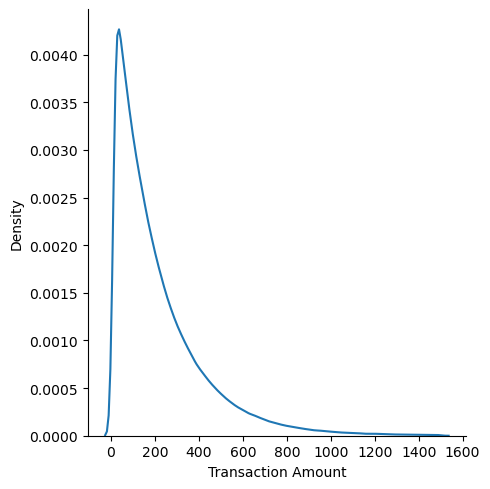

In [13]:
Ecommerce = Ecommerce[Ecommerce['Transaction Amount'] <= 1500]
Ecommerce['Transaction Amount'].max()

sns.displot(Ecommerce['Transaction Amount'], kind='kde')



In [14]:
Ecommerce['Transaction Amount'].max()

1499.95

In [15]:
# len((Ecommerce))
print('hey')
len((Ecommerce['Payment Method']))

hey


1465016

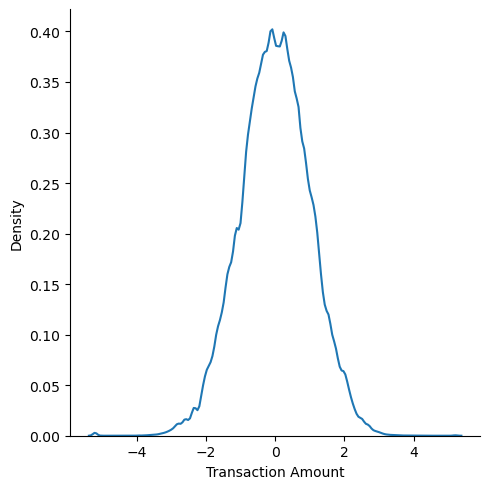

In [16]:
qt = QuantileTransformer(output_distribution='normal', random_state= 42)
Ecommerce['Transaction Amount'] = qt.fit_transform(Ecommerce[['Transaction Amount']])
sns.displot(Ecommerce['Transaction Amount'], kind='kde')

array(['bank transfer', 'debit card', 'PayPal', 'credit card'],
      dtype=object)

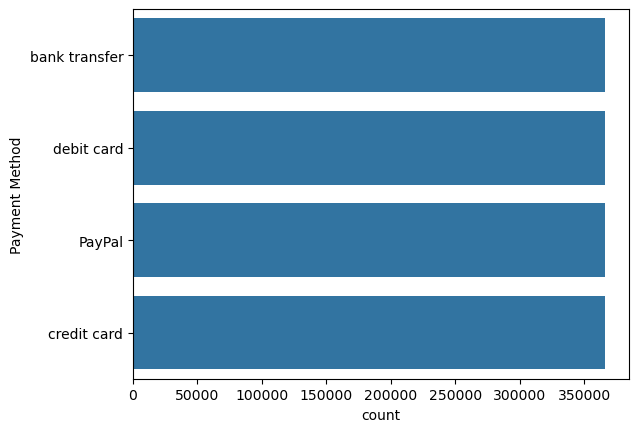

In [17]:
sns.countplot(Ecommerce['Payment Method'])
Ecommerce['Payment Method'].unique()




array(['electronics', 'home & garden', 'clothing', 'toys & games',
       'health & beauty'], dtype=object)

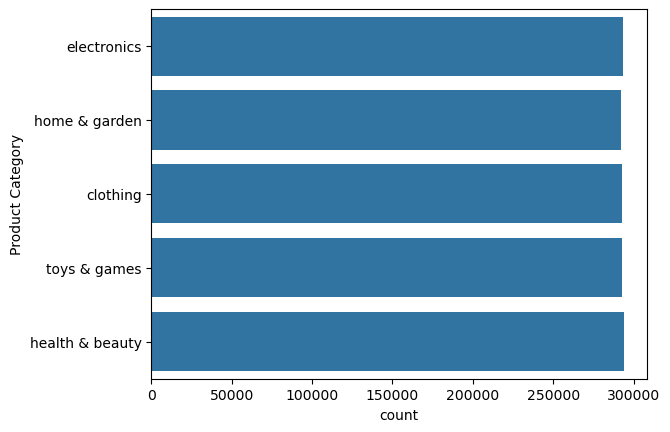

In [18]:
sns.countplot(Ecommerce['Product Category'])
Ecommerce['Product Category'].unique()

In [25]:
Ecommerce.isnull().sum()   # so there is no null values

Transaction ID        0
Customer ID           0
Transaction Amount    0
Transaction Date      0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Customer Location     0
Device Used           0
IP Address            0
Shipping Address      0
Billing Address       0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64

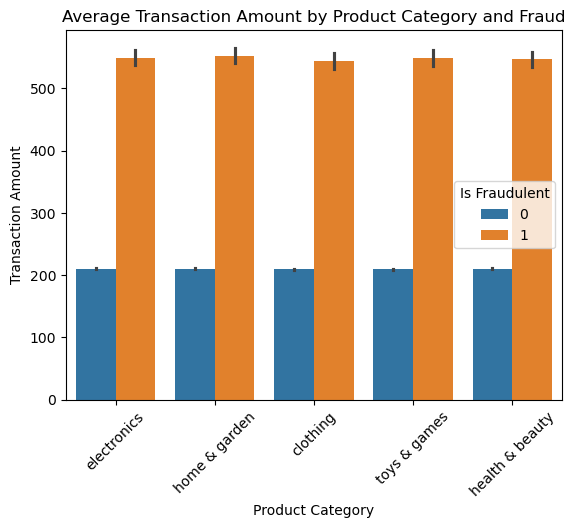

In [15]:
sns.barplot(
    x='Product Category',
    y='Transaction Amount',
    hue='Is Fraudulent',
    data=Ecommerce,
    estimator=np.mean
)
plt.title('Average Transaction Amount by Product Category and Fraud')
plt.xticks(rotation=45)
plt.show()


In [16]:
# some columns we are drop because some columns are not useful 
print(Ecommerce.columns)

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Date', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'IP Address',
       'Shipping Address', 'Billing Address', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour'],
      dtype='object')


In [29]:
Ecommerce = Ecommerce.drop( columns= ['Transaction ID','Customer ID','Shipping Address','Billing Address'])

In [17]:
print(Ecommerce.columns.tolist())


['Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'IP Address', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']


In [18]:

Ecommerce.head()

,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Is Fraudulent,Account Age Days,Transaction Hour
0,-0.793625,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,0,30,5
1,1.006383,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,0,72,8
2,-0.102838,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,0,63,3
3,0.400275,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,0,124,20
4,-0.190200,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,0,158,5


In [19]:

Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1465016 entries, 0 to 1472951
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction Amount  1465016 non-null  float64
 1   Transaction Date    1465016 non-null  object 
 2   Payment Method      1465016 non-null  object 
 3   Product Category    1465016 non-null  object 
 4   Quantity            1465016 non-null  int64  
 5   Customer Age        1465016 non-null  int64  
 6   Customer Location   1465016 non-null  object 
 7   Device Used         1465016 non-null  object 
 8   IP Address          1465016 non-null  object 
 9   Is Fraudulent       1465016 non-null  int64  
 10  Account Age Days    1465016 non-null  int64  
 11  Transaction Hour    1465016 non-null  int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 145.3+ MB


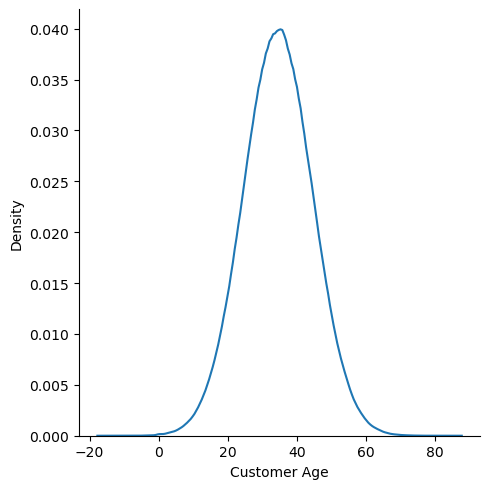

In [20]:
Ecommerce['Customer Age'].unique()
sns.displot(Ecommerce['Customer Age'], kind = 'kde')

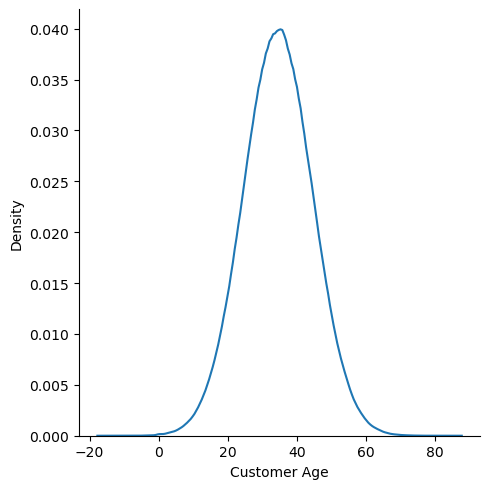

In [36]:
sns.displot(Ecommerce['Customer Age'], kind = 'kde')

In [23]:
check_customer_Age = ((Ecommerce['Customer Age'] >= -16) & (Ecommerce['Customer Age'] <= 1)).sum()


In [24]:
Ecommerce['Customer Age'].min()


-16

In [25]:
Ecommerce = Ecommerce[(Ecommerce['Customer Age'] >= 1)]
Ecommerce['Customer Age'].max()



86

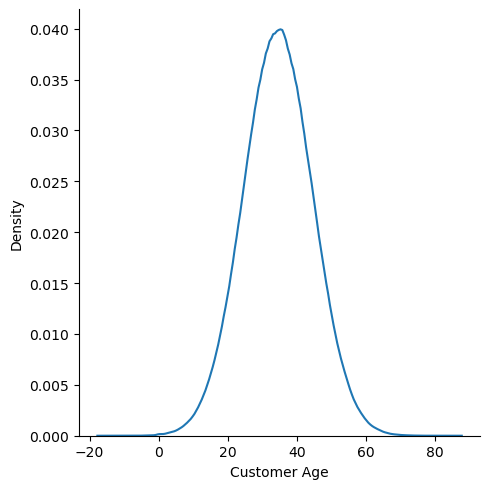

In [39]:
sns.displot(Ecommerce['Customer Age'], kind = 'kde')

In [26]:
len(Ecommerce['Customer Age'])

1464497

In [27]:
#Ecommerce['Customer Age'] = Ecommerce['Customer Age'].astype(int)
#print(Ecommerce['Customer Age'].dtype )
#Ecommerce['Customer Age'].mean()

In [28]:
# we calculate age of customer which is real so we do not consider negative and below 13 age for median

#customer_age_mean = Ecommerce[Ecommerce['Customer Age']> 13]['Customer Age'].mean()
#print(customer_age_mean)

In [29]:
check = ((Ecommerce['Customer Age'] >= -16) & (Ecommerce['Customer Age'] < 1)).sum()
print(check)

0


In [30]:
# lets replace negative and below 13 age value with mean

#Ecommerce.loc[(Ecommerce['Customer Age'] >= -16) & (Ecommerce['Customer Age'] <= 13), 'Customer Age'] = customer_age_mean


In [31]:

Ecommerce['Customer Age'].describe()

count    1.464497e+06
mean     3.452471e+01
std      9.981731e+00
min      1.000000e+00
25%      2.800000e+01
50%      3.500000e+01
75%      4.100000e+01
max      8.600000e+01
Name: Customer Age, dtype: float64

In [61]:
print(Ecommerce['Customer Age'].dtype)


int64


In [63]:
print(Ecommerce['Transaction Date'].dtype)

object


In [65]:
Ecommerce['Transaction Date'].info()

<class 'pandas.core.series.Series'>
Index: 1464497 entries, 0 to 1472951
Series name: Transaction Date
Non-Null Count    Dtype 
--------------    ----- 
1464497 non-null  object
dtypes: object(1)
memory usage: 22.3+ MB


In [67]:
Ecommerce['Transaction Date'] = pd.to_datetime(Ecommerce['Transaction Date'])
Ecommerce['Transaction Year'] = Ecommerce['Transaction Date'].dt.year
Ecommerce['Transaction Month'] = Ecommerce['Transaction Date'].dt.month
Ecommerce['Transaction Day'] = Ecommerce['Transaction Date'].dt.day
Ecommerce['Transaction Weekday'] = Ecommerce['Transaction Date'].dt.dayofweek

In [69]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Transaction Amount   1464497 non-null  float64       
 1   Transaction Date     1464497 non-null  datetime64[ns]
 2   Payment Method       1464497 non-null  object        
 3   Product Category     1464497 non-null  object        
 4   Quantity             1464497 non-null  int64         
 5   Customer Age         1464497 non-null  int64         
 6   Customer Location    1464497 non-null  object        
 7   Device Used          1464497 non-null  object        
 8   IP Address           1464497 non-null  object        
 9   Is Fraudulent        1464497 non-null  int64         
 10  Account Age Days     1464497 non-null  int64         
 11  Transaction Hour     1464497 non-null  int64         
 12  Transaction Year     1464497 non-null  int32         
 13  Tr

In [70]:
Ecommerce = pd.get_dummies(Ecommerce, columns=['Payment Method','Product Category','Device Used'])

In [73]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 25 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Transaction Amount                1464497 non-null  float64       
 1   Transaction Date                  1464497 non-null  datetime64[ns]
 2   Quantity                          1464497 non-null  int64         
 3   Customer Age                      1464497 non-null  int64         
 4   Customer Location                 1464497 non-null  object        
 5   IP Address                        1464497 non-null  object        
 6   Is Fraudulent                     1464497 non-null  int64         
 7   Account Age Days                  1464497 non-null  int64         
 8   Transaction Hour                  1464497 non-null  int64         
 9   Transaction Year                  1464497 non-null  int32         
 10  Transaction Month      

In [75]:
#Ecommerce['Transaction Year'].unique()

In [77]:
Ecommerce['Device Used_desktop'] = Ecommerce['Device Used_desktop'].astype(int)
Ecommerce['Transaction Weekday'] = Ecommerce['Transaction Weekday'].astype(int)              
Ecommerce['Payment Method_PayPal']  = Ecommerce['Payment Method_PayPal'].astype(int)                   
Ecommerce['Payment Method_bank transfer']  = Ecommerce['Payment Method_bank transfer'].astype(int)       
Ecommerce['Payment Method_credit card']   = Ecommerce['Payment Method_credit card'].astype(int)     
Ecommerce['Payment Method_debit card']   = Ecommerce['Payment Method_debit card'].astype(int)              
Ecommerce['Product Category_clothing']     = Ecommerce['Product Category_clothing'].astype(int)            
Ecommerce['Product Category_electronics']    = Ecommerce['Product Category_electronics'].astype(int)          
Ecommerce['Product Category_health & beauty'] = Ecommerce['Product Category_health & beauty'].astype(int)          
Ecommerce['Product Category_home & garden']   = Ecommerce['Product Category_home & garden'].astype(int)          
Ecommerce['Product Category_toys & games']  = Ecommerce['Product Category_toys & games'].astype(int)          
Ecommerce['Device Used_desktop']        = Ecommerce['Device Used_desktop'].astype(int)             
Ecommerce['Device Used_mobile']         = Ecommerce['Device Used_mobile'].astype(int)                
Ecommerce['Device Used_tablet']          = Ecommerce['Device Used_tablet'].astype(int)

In [79]:
#sns.countplot(x='Payment_Method', hue='Fraud?', data=df)
#plt.title('Payment Method Distribution by Fraud Status')
#plt.xticks(rotation=45)
#plt.show()


In [82]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 25 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Transaction Amount                1464497 non-null  float64       
 1   Transaction Date                  1464497 non-null  datetime64[ns]
 2   Quantity                          1464497 non-null  int64         
 3   Customer Age                      1464497 non-null  int64         
 4   Customer Location                 1464497 non-null  object        
 5   IP Address                        1464497 non-null  object        
 6   Is Fraudulent                     1464497 non-null  int64         
 7   Account Age Days                  1464497 non-null  int64         
 8   Transaction Hour                  1464497 non-null  int64         
 9   Transaction Year                  1464497 non-null  int32         
 10  Transaction Month      

In [84]:
Ecommerce= Ecommerce.drop(columns = ['Transaction Year'])

In [86]:
Ecommerce.corr(numeric_only=True)

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour,Transaction Month,Transaction Day,Transaction Weekday,Payment Method_PayPal,...,Payment Method_credit card,Payment Method_debit card,Product Category_clothing,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_desktop,Device Used_mobile,Device Used_tablet
Transaction Amount,1.000000,-0.000745,0.000195,0.095215,-0.011124,-0.009299,-0.000717,0.002138,-0.000217,-0.000911,...,0.000821,0.000500,-0.001417,0.000837,0.000099,0.000031,0.000450,0.000274,0.000252,-0.000526
Quantity,-0.000745,1.000000,0.000903,-0.001193,0.001238,0.000083,-0.001113,0.000853,0.001104,0.000516,...,0.000558,0.000355,-0.000328,0.001408,-0.000204,-0.000697,-0.000182,-0.000180,-0.000365,0.000545
Customer Age,0.000195,0.000903,1.000000,-0.001313,0.000565,0.001390,-0.000494,-0.000300,0.000272,0.000855,...,-0.000476,-0.000902,0.000336,-0.000720,0.001018,0.000159,-0.000792,-0.000141,0.000856,-0.000715
Is Fraudulent,0.095215,-0.001193,-0.001313,1.000000,-0.130378,-0.108051,0.000554,-0.000016,-0.000642,-0.000080,...,-0.000920,0.000440,0.000670,-0.001480,0.000407,-0.000149,0.000553,-0.001062,0.001310,-0.000249
Account Age Days,-0.011124,0.001238,0.000565,-0.130378,1.000000,0.015010,-0.000155,-0.000905,0.000769,-0.000193,...,-0.000779,-0.000649,-0.000637,0.001223,-0.000848,-0.000557,0.000819,0.000073,-0.000503,0.000430
Transaction Hour,-0.009299,0.000083,0.001390,-0.108051,0.015010,1.000000,-0.009445,0.005649,0.002480,-0.001041,...,0.000103,0.000810,-0.000680,-0.001304,-0.000345,0.001849,0.000483,0.000622,0.000008,-0.000630
Transaction Month,-0.000717,-0.001113,-0.000494,0.000554,-0.000155,-0.009445,1.000000,-0.086872,0.009827,-0.000094,...,0.000021,-0.000609,-0.000378,-0.000068,0.000304,-0.000288,0.000430,0.000683,-0.001357,0.000674
Transaction Day,0.002138,0.000853,-0.000300,-0.000016,-0.000905,0.005649,-0.086872,1.000000,0.045583,0.000181,...,0.002217,-0.001443,-0.001129,-0.000829,0.000994,-0.000451,0.001415,-0.000352,0.001199,-0.000848
Transaction Weekday,-0.000217,0.001104,0.000272,-0.000642,0.000769,0.002480,0.009827,0.045583,1.000000,0.001862,...,-0.002018,0.000923,-0.000475,-0.000397,-0.000700,0.000705,0.000869,-0.000551,-0.000564,0.001115
Payment Method_PayPal,-0.000911,0.000516,0.000855,-0.000080,-0.000193,-0.001041,-0.000094,0.000181,0.001862,1.000000,...,-0.333277,-0.333199,0.000054,-0.000978,0.001083,0.000595,-0.000754,0.000804,-0.000158,-0.000645


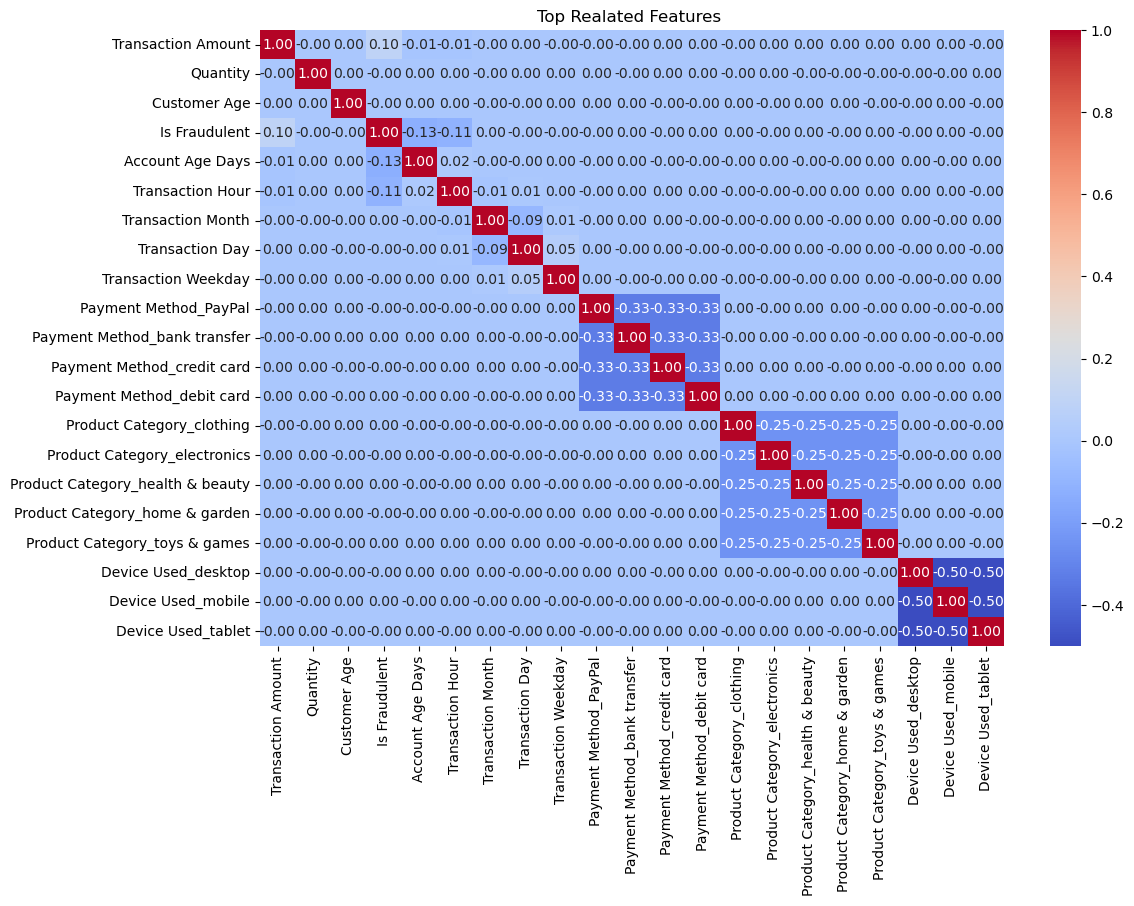

In [89]:
plt.figure(figsize=(12,8))
sns.heatmap(Ecommerce.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt= '0.2f')
plt.title("Top Realated Features ")
plt.show()

In [91]:
Ecommerce['Transaction Date']


0         2024-02-20 05:58:41
1         2024-02-25 08:09:45
2         2024-03-18 03:42:55
3         2024-03-16 20:41:31
4         2024-01-15 05:08:17
                  ...        
1472947   2024-01-12 23:39:55
1472948   2024-03-27 04:31:45
1472949   2024-01-31 23:51:42
1472950   2024-01-12 16:21:32
1472951   2024-02-19 18:57:20
Name: Transaction Date, Length: 1464497, dtype: datetime64[ns]

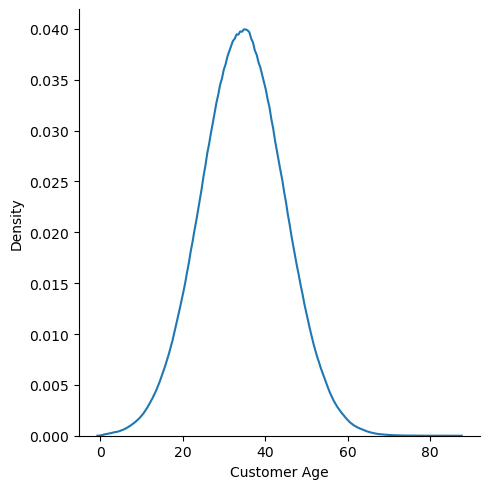

In [92]:

sns.displot(Ecommerce['Customer Age'], kind= 'kde')




In [93]:
#Ecommerce['Customer Age'].skew()
#Ecommerce['Customer Age_log'] = np.log(Ecommerce['Customer Age'])
#sns.displot(Ecommerce['Customer Age_log'], kind='kde')

In [94]:
#from sklearn.preprocessing import QuantileTransformer
#qt = QuantileTransformer(output_distribution='normal', random_state= 42)
#Ecommerce['Customer Age_qt'] = qt.fit_transform(Ecommerce[['Customer Age']])
Ecommerce['Customer_Age_qt'] = qt.fit_transform(Ecommerce[['Customer Age']])

In [95]:
# sns.displot(Ecommerce['Customer_Age_qt'], kind='kde')

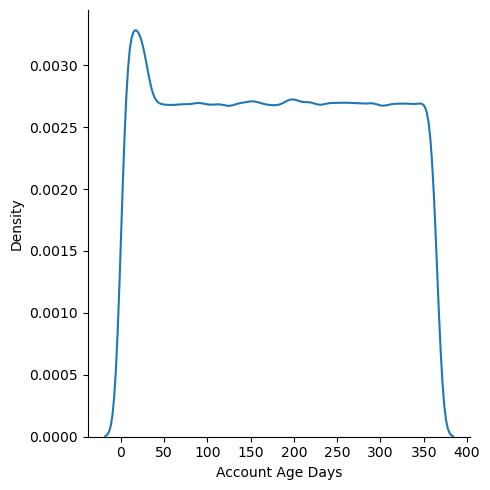

In [96]:
sns.displot(Ecommerce['Account Age Days'],kind = 'kde')

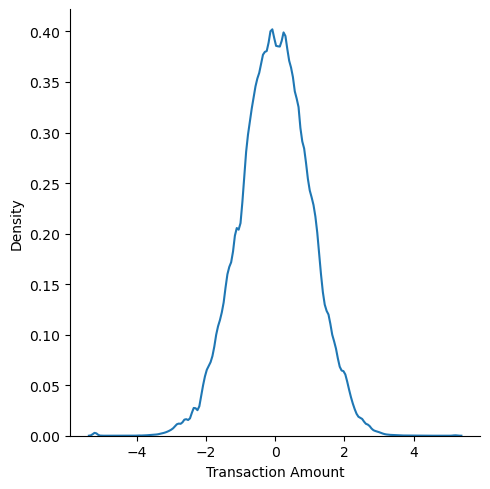

In [97]:
sns.displot(Ecommerce['Transaction Amount'], kind = 'kde')

In [106]:
Ecommerce['Device Used_desktop'].info()

<class 'pandas.core.series.Series'>
Index: 1464497 entries, 0 to 1472951
Series name: Device Used_desktop
Non-Null Count    Dtype
--------------    -----
1464497 non-null  int32
dtypes: int32(1)
memory usage: 16.8 MB


In [108]:


# Ecommerce['Account_Age_BoxCox'], fitted_lambda = boxcox(Ecommerce['Account Age Days'])
#sns.displot(Ecommerce['Account_Age_BoxCox'], kind= 'kde')

#Ecommerce['Account_Age_qt'] = qt.fit_transform(Ecommerce[['Account Age Days']])
#sns.displot(Ecommerce['Account_Age_qt'], kind = 'kde')

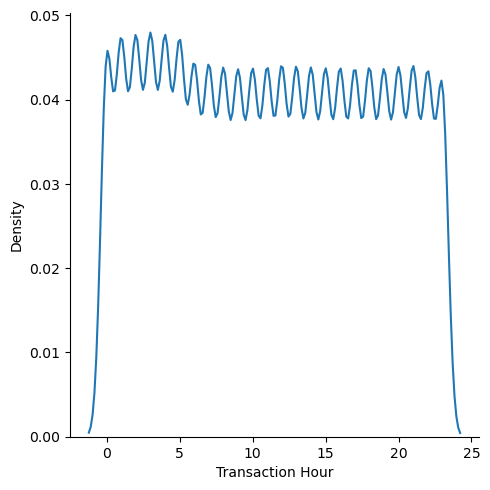

In [110]:
Ecommerce['Transaction Hour'].shape
sns.displot(Ecommerce['Transaction Hour'],kind = 'kde')  # this graph is nearly syemmetric and this is hour 

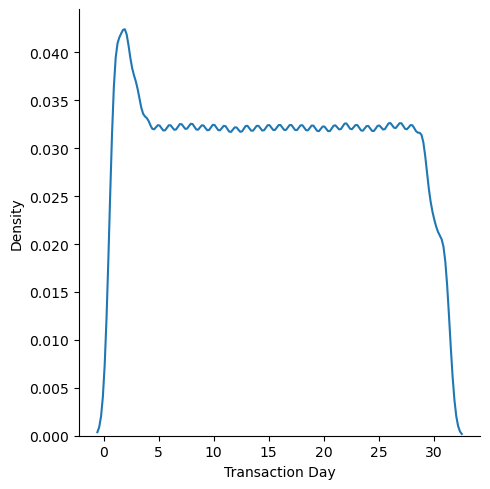

In [111]:
Ecommerce['Transaction Day'].shape
sns.displot(Ecommerce['Transaction Day'],kind = 'kde')

In [ ]:
Ecommerce.info()

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Load your dataset
# df = pd.read_csv("ecommerce.csv")

target = "is_fraud"  # change if your column name is different

# 1. Boxplot: Transaction Amount vs Target
plt.figure(figsize=(8,5))
sns.boxplot(x=target, y="transaction_amount", data=df)
plt.title("Transaction Amount by Fraud Status")
plt.show()

# 2. Violin plot: Transaction Hour vs Target
plt.figure(figsize=(8,5))
sns.violinplot(x=target, y="transaction_hour", data=df)
plt.title("Transaction Hour Distribution by Fraud Status")
plt.show()

# 3. Countplot: Device Type vs Target (hue)
plt.figure(figsize=(8,5))
sns.countplot(x="device_type", hue=target, data=df)
plt.title("Device Type Counts by Fraud Status")
plt.show()

# 4. Heatmap: Correlation of numeric features with Target
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), annot=True, cmap="coolwarm")
plt.title("Correlation of Features with Fraud")
plt.show()

# 5. Scatterplot: Transaction Amount vs Customer Age (colored by Target)
plt.figure(figsize=(8,5))
sns.scatterplot(x="customer_age", y="transaction_amount", hue=target, data=df, alpha=0.6)
plt.title("Transaction Amount vs Customer Age by Fraud Status")
plt.show()

# 6. Pairplot: Select top features with Target
top_features = ["transaction_amount", "transaction_hour", "customer_age", target]
sns.pairplot(df[top_features], hue=target, diag_kind="kde")
plt.suptitle("Pairplot of Top Features by Fraud Status", y=1.02)
plt.show()


In [113]:
negative = (Ecommerce['Transaction Day'] < 0).sum()

print("Number of customers with negative:", negative)
#Ecommerce['Transaction Day_log'] = np.log1p(Ecommerce['Transaction Day'])
#Ecommerce['Transaction Day_qt'] = qt.fit_transform(Ecommerce[['Transaction Day']])

Number of customers with negative: 0


In [114]:
#sns.displot(Ecommerce['Transaction Day_log'], kind= 'kde')

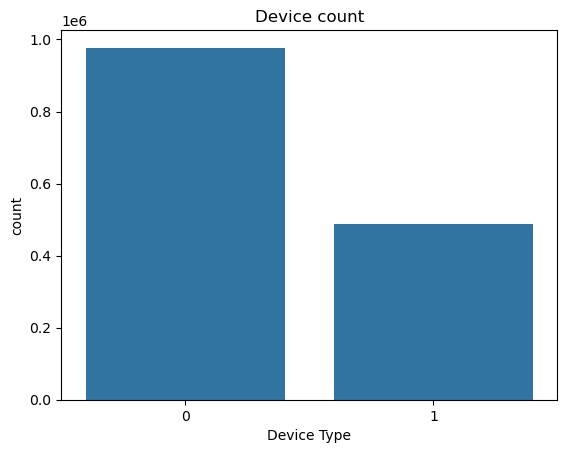

In [115]:
sns.countplot(x="Device Used_desktop", data=Ecommerce )
plt.title("Device count")
plt.xlabel("Device Type")
plt.ylabel("count")
plt.show()

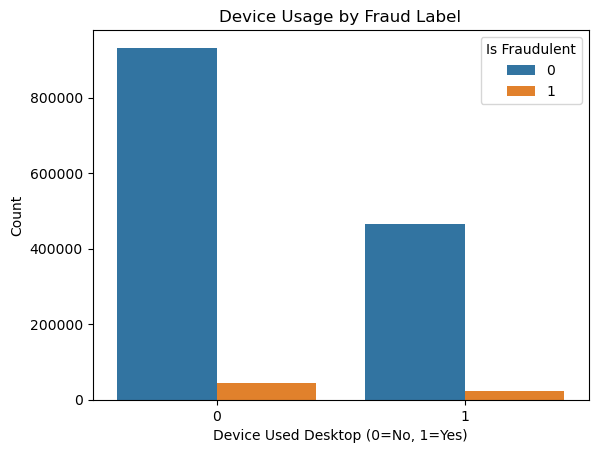

In [116]:
# Check distribution of device types per fraud class
sns.countplot(x='Device Used_desktop', hue='Is Fraudulent', data=Ecommerce)
plt.title("Device Usage by Fraud Label")
plt.xlabel("Device Used Desktop (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()


In [73]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 25 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Transaction Amount                1464497 non-null  float64       
 1   Transaction Date                  1464497 non-null  datetime64[ns]
 2   Quantity                          1464497 non-null  int64         
 3   Customer Age                      1464497 non-null  int64         
 4   Customer Location                 1464497 non-null  object        
 5   IP Address                        1464497 non-null  object        
 6   Is Fraudulent                     1464497 non-null  int64         
 7   Account Age Days                  1464497 non-null  int64         
 8   Transaction Hour                  1464497 non-null  int64         
 9   Transaction Year                  1464497 non-null  int32         
 10  Transaction Month      

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Load your dataset
# df = pd.read_csv("ecommerce.csv")

target = "Is Fraudulent"  # change if your column name is different
df = Ecommerce
# 1. Boxplot: Transaction Amount vs Target
plt.figure(figsize=(8,5))
sns.boxplot(x=target, y="Transaction Amount", data=df)
plt.title("Transaction Amount by Fraud Status")
plt.show()

# 2. Violin plot: Transaction Hour vs Target
plt.figure(figsize=(8,5))
sns.violinplot(x=target, y="Transaction Hour", data=df)
plt.title("Transaction Hour Distribution by Fraud Status")
plt.show()



# 4. Heatmap: Correlation of numeric features with Target
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), annot=True, cmap="coolwarm")
plt.title("Correlation of Features with Fraud")
plt.show()

# 5. Scatterplot: Transaction Amount vs Customer Age (colored by Target)
plt.figure(figsize=(8,5))
sns.scatterplot(x="Customer Age", y="Transaction Amount", hue=target, data=df, alpha=0.6)
plt.title("Transaction Amount vs Customer Age by Fraud Status")
plt.show()

# 6. Pairplot: Select top features with Target
top_features = ["Transaction Amount", "Transaction Hour", "Customer Age", target]
sns.pairplot(df[top_features], hue=target, diag_kind="kde")
plt.suptitle("Pairplot of Top Features by Fraud Status", y=1.02)
plt.show()


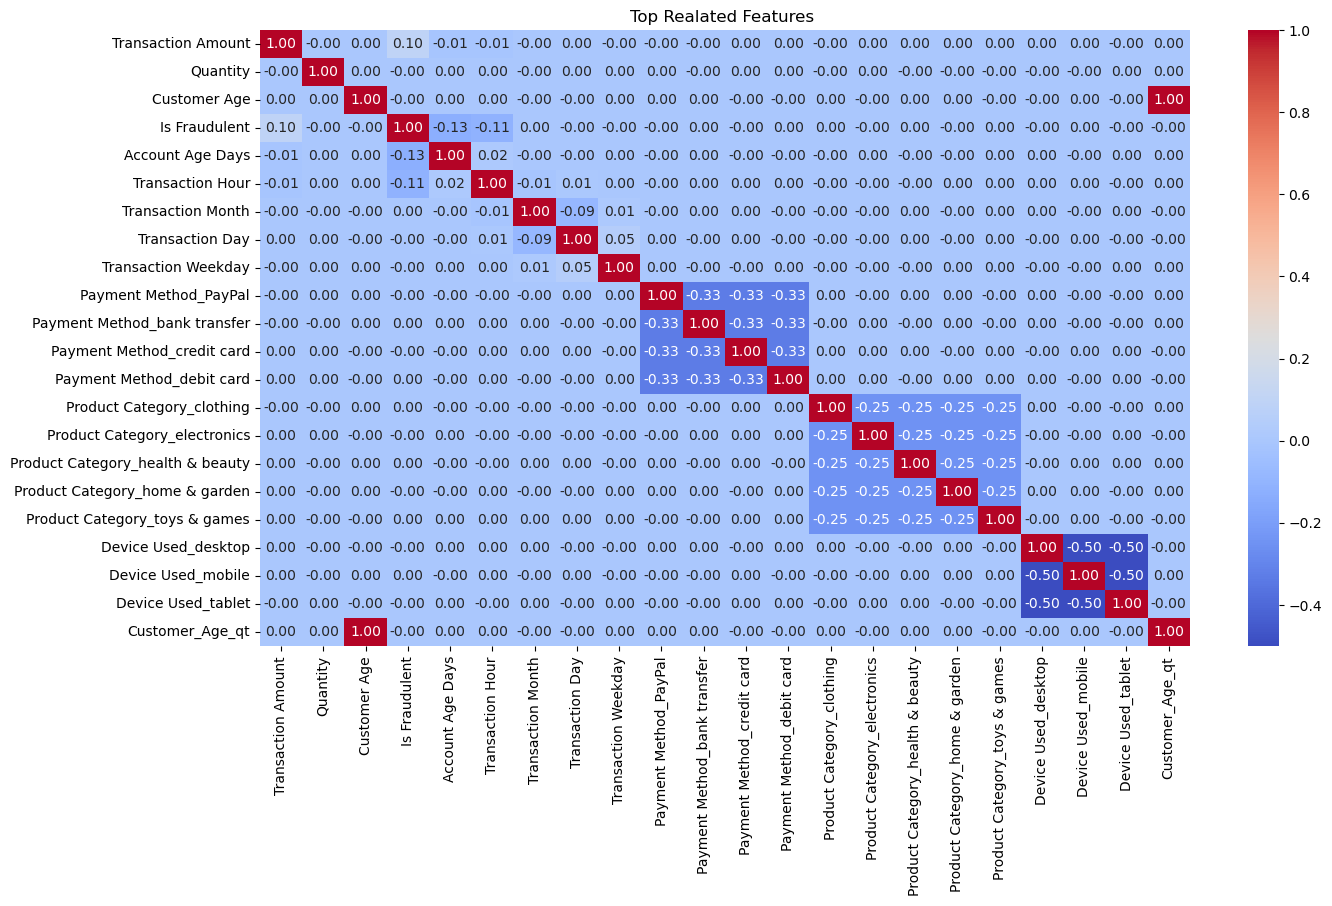

In [118]:
plt.figure(figsize=(15,8))
sns.heatmap(Ecommerce.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt= '0.2f')
plt.title("Top Realated Features ")
plt.show()

In [120]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 25 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Transaction Amount                1464497 non-null  float64       
 1   Transaction Date                  1464497 non-null  datetime64[ns]
 2   Quantity                          1464497 non-null  int64         
 3   Customer Age                      1464497 non-null  int64         
 4   Customer Location                 1464497 non-null  object        
 5   IP Address                        1464497 non-null  object        
 6   Is Fraudulent                     1464497 non-null  int64         
 7   Account Age Days                  1464497 non-null  int64         
 8   Transaction Hour                  1464497 non-null  int64         
 9   Transaction Month                 1464497 non-null  int32         
 10  Transaction Day        

In [121]:

X = Ecommerce.drop(columns = ['Is Fraudulent','Transaction Date','Customer Location','IP Address'],axis =1)
Y = Ecommerce['Is Fraudulent']

In [122]:
Ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 25 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Transaction Amount                1464497 non-null  float64       
 1   Transaction Date                  1464497 non-null  datetime64[ns]
 2   Quantity                          1464497 non-null  int64         
 3   Customer Age                      1464497 non-null  int64         
 4   Customer Location                 1464497 non-null  object        
 5   IP Address                        1464497 non-null  object        
 6   Is Fraudulent                     1464497 non-null  int64         
 7   Account Age Days                  1464497 non-null  int64         
 8   Transaction Hour                  1464497 non-null  int64         
 9   Transaction Month                 1464497 non-null  int32         
 10  Transaction Day        

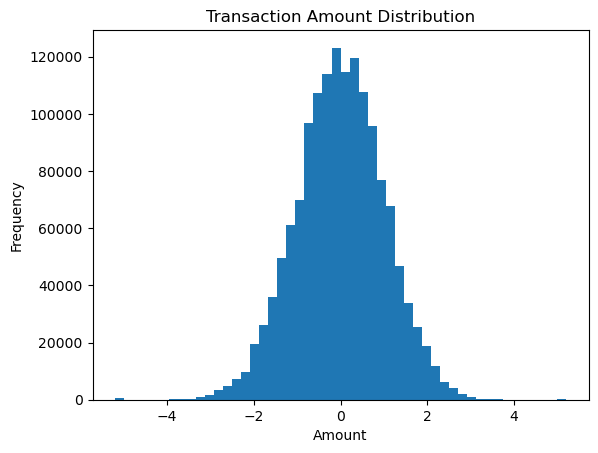

In [123]:


plt.hist(Ecommerce['Transaction Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()



In [125]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464497 entries, 0 to 1472951
Data columns (total 21 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   Transaction Amount                1464497 non-null  float64
 1   Quantity                          1464497 non-null  int64  
 2   Customer Age                      1464497 non-null  int64  
 3   Account Age Days                  1464497 non-null  int64  
 4   Transaction Hour                  1464497 non-null  int64  
 5   Transaction Month                 1464497 non-null  int32  
 6   Transaction Day                   1464497 non-null  int32  
 7   Transaction Weekday               1464497 non-null  int32  
 8   Payment Method_PayPal             1464497 non-null  int32  
 9   Payment Method_bank transfer      1464497 non-null  int32  
 10  Payment Method_credit card        1464497 non-null  int32  
 11  Payment Method_debit card         1464497 

In [126]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)


smote = SMOTE(random_state=42)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)


model = LogisticRegression()
model.fit(X_train_bal, Y_train_bal)

y_pred = model.predict(X_test)

print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

C:\Users\Khushal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Khushal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Khushal\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Khushal\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Khushal\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi

[[279136    421]
 [ 12948    395]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    279557
           1       0.48      0.03      0.06     13343

    accuracy                           0.95    292900
   macro avg       0.72      0.51      0.52    292900
weighted avg       0.93      0.95      0.93    292900



In [128]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print(" before SMOTE")
print(pd.Series(Y_train).value_counts())
smote = SMOTE(random_state=42)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)

print(" after SMOTE:")
print(pd.Series(Y_train_bal).value_counts())

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_bal, Y_train_bal)

y_pred = model.predict(X_test)

print("Confusion Matrix")
print(confusion_matrix(Y_test, y_pred))

print("Classification Repor:")
print(classification_report(Y_test, y_pred))


 before SMOTE
Is Fraudulent
0    1118227
1      53370
Name: count, dtype: int64
 after SMOTE:
Is Fraudulent
0    1118227
1    1118227
Name: count, dtype: int64
Confusion Matrix
[[278287   1270]
 [ 12314   1029]]
Classification Repor:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    279557
           1       0.45      0.08      0.13     13343

    accuracy                           0.95    292900
   macro avg       0.70      0.54      0.55    292900
weighted avg       0.93      0.95      0.94    292900



In [129]:
#X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state= 2)

In [130]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [131]:


model = LogisticRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

# Evaluation
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

C:\Users\Khushal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[279557      0]
 [ 13335      8]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98    279557
           1       1.00      0.00      0.00     13343

    accuracy                           0.95    292900
   macro avg       0.98      0.50      0.49    292900
weighted avg       0.96      0.95      0.93    292900



In [132]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_bal, Y_train_bal)


y_pred = xgb_model.predict(X_train_bal)

accuracy = accuracy_score(Y_train_bal, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

C:\Users\Khushal\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:47:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 97.24 %


Accuracy: 97.24 %
Precision: 0.9954
Recall: 0.9491
F1 Score: 0.9717


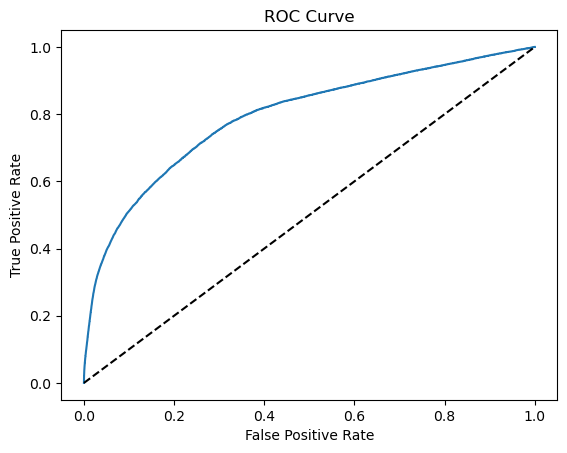

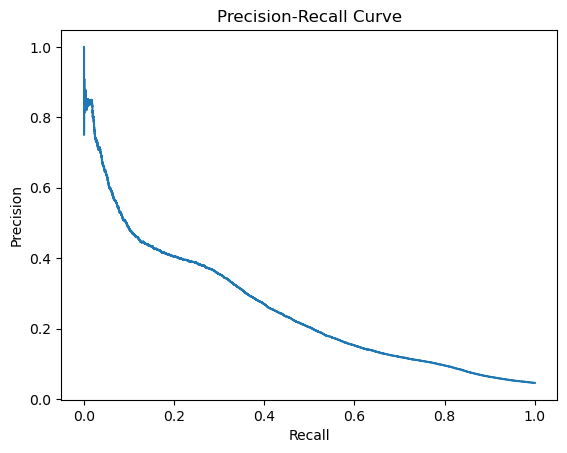

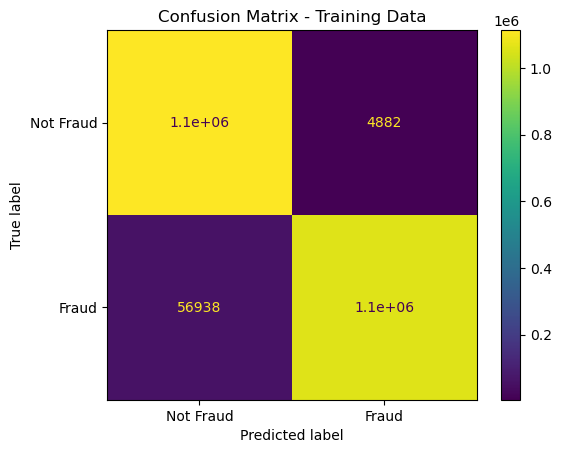

In [133]:



y_pred = xgb_model.predict(X_train_bal)

accuracy = accuracy_score(Y_train_bal, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

precision = precision_score(Y_train_bal, y_pred)
recall = recall_score(Y_train_bal, y_pred)
f1 = f1_score(Y_train_bal, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

metrics = {
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4)
}


y_scores = xgb_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(Y_test, y_scores)
roc_auc = roc_auc_score(Y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(Y_test, y_scores)

plt.figure()
plt.plot(recall_vals, precision_vals, label='Precision-Recall Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

cm = confusion_matrix(Y_train_bal, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
disp.plot()
plt.title("Confusion Matrix - Training Data")
plt.show()